<a href="https://colab.research.google.com/github/deveveryday/aws-power-of-the-words-eda/blob/main/project_eda_aws_100426.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
       #
#
#

In [4]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

path = "/content/drive/MyDrive/cdai/ColabNotebooks/csv/"

def read(filename):
  return pd.read_csv(path + filename)


def initial_analysis(name, df):
  df = tables[name]
  print("--" * 10)
  print("--" * 10)
  print(name,"\n")
  print("--" * 10)
  df.info()

  print("--" * 10)
  print(df.describe())
  print("--" * 10)
  print("------head--------")
  print(df.head())
  print("--" * 10)
  print("------tail--------")
  print(df.tail())
  print("--" * 10)
  print("------max--------")
  print(df.max())
  print("--" * 10)
  print("------min--------")
  print(df.max())
  print("--" * 10)
  print("--" * 10)
  print("------dtypes--------")
  print(df.dtypes)
  display(df.head())

df_review = read("avaliacoes.csv")
df_geo = read("geolocalizacao.csv")
df_clients = read("clientes.csv")
df_products = read("produtos.csv")
df_aux = read("tabela_auxiliar.csv")
df_sales = read("pedidos.csv")
df_payments = read("pagamentos.csv")
df_sales_items = read("itens_pedidos.csv")
df_sellers = read("vendedores.csv")

tables = {
    "review": df_review,
    "geo" : df_geo,
    "clients" : df_clients,
    "products" : df_products,
    "aux" : df_aux,
    "payments" : df_payments,
    "sales_items" : df_sales_items,
    "sellers" : df_sellers,
    "sales" : df_sales
}


In [8]:
#review_id
#order_id
#review_score
#review_comment_title
#review_comment_message
#review_creation_date

review_columns = ["review_id", "review_score", "review_comment_title", "review_comment_message"]
df_review_clean = df_review[review_columns].copy()

In [ ]:
def search(regex: str, df, case=False):
    """Search all the text columns of `df`, return rows with any matches."""
    textlikes = df.select_dtypes(include=[object, "string"])
    return df[
        textlikes.apply(
            lambda column: column.str.contains(regex, regex=True, case=case, na=False)
        ).any(axis=1)
    ]

In [9]:
df_review_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               99224 non-null  object
 1   review_score            99224 non-null  int64 
 2   review_comment_title    11568 non-null  object
 3   review_comment_message  40977 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.0+ MB


In [ ]:
#df_review_clean.select_dtypes(include="object").columns
#df_review_clean.shape
#df_review_clean.info()
#df_review_clean.describe().T

#total 99224

#verificando nulos
#message null = 58247
#message not null = 40977
#
#df_review_clean.isnull().sum()
#df_review_clean.info()
#df_review.duplicated()


#Criei uma coluna informando onde tem comentário vazio
#Vou usar para somar com Avaliacao
#Fiz função para pontuar comentário negativo
#Fiz função para pontuar comentário positivo
#criei coluna com esses pontos
#comparar com a pontuação dada pelo usuário

#consegui fazer um decode de comentário mais pontuação
#estou respondendo com conta.
#dúvida: como responder com texto??
#preciso corrigir portugues??
#preciso já deixar tudo minúsculo ou posso somente em cada operação??
#um texto fica mais ou menos positivo conforme mais coisas negativas ou positivas vai tendo?

#• Comentários positivos estão associados a notas altas?
# As vezes, existe comentário positivo com nota baixa

#• Comentários negativos estão associados a notas baixas?
# As vezes, existe comentário negativo com nota alta

#• Existem casos de incoerência (ex: comentário positivo com nota baixa)?
# Sim

#• Quais palavras aparecem com maior frequência em avaliações boas e ruins?
# Produto, antes do prazo,


df_review_clean['review_has_message'] = df_review_clean["review_comment_message"].notnull()
df_review_clean['review_has_title'] = df_review_clean["review_comment_title"].notnull()

#create a new column named review_empty_score
#if message is null 1


NameError: name 'df_review_clean' is not defined

In [ ]:
search("NaN", df_review_clean, False)


,review_id,review_score,review_comment_title,review_comment_message,has_review_message,review_has_message,review_has_title
0,7bc2406110b926393aa56f80a40eba40,4,NaN,NaN,False,False,True
1,80e641a11e56f04c1ad469d5645fdfde,5,NaN,NaN,False,False,True
2,228ce5500dc1d8e020d8d1322874b6f0,5,NaN,NaN,False,False,True
3,e64fb393e7b32834bb789ff8bb30750e,5,NaN,Recebi bem antes do prazo estipulado.,True,True,True
4,f7c4243c7fe1938f181bec41a392bdeb,5,NaN,Parabéns lojas lannister adorei comprar pela I...,True,True,True
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,5,NaN,NaN,False,False,True
99220,f3897127253a9592a73be9bdfdf4ed7a,5,NaN,NaN,False,False,True
99221,b3de70c89b1510c4cd3d0649fd302472,5,NaN,"Excelente mochila, entrega super rápida. Super...",True,True,True
99222,1adeb9d84d72fe4e337617733eb85149,4,NaN,NaN,False,False,True


In [14]:
normal_words = []
good_words = ["muito","bom","gosto", "legal", "bacana", "adorei", "otimo", "antes do prazo"]
great_words = []

negative_words = ["não recebi", "nada de chegar", "apesar", "atrazo", "atraso"]
bad_words = []

# IF score = 5
#  if has normal words
#  if has good words
#  if has great words

# IF score = 4
#  if has normal words
#  if has good words
#  if has great words

# IF score = 3
#  if has normal words
#  if has good words
#  if has great words

# IF score = 2
#  if has normal words
#  if has good words
#  if has great words

# IF score = 1
#  if has normal words
#  if has good words
#  if has great words


positive_words = [
    "abençoado","abençoar","abertura","abnegação","abraço","abrigo","absoluto","abundância","ação","aceitação","aceitar","acessível","aclamação","aclamado","aconchegante","aconchegar","aconchego","acreditar","adaptabilidade","adaptável","adequado","admiração","admirável","adoração","adorar","adorável","afabilidade","afável","afirmação","afirmativo","agilidade","agradar","agradável","agradecer","agradecimento","ajuda","ajudar","alcançar","alegre","alegria","alicerce","alma","altruísmo","altruísta","amabilidade","amar","amável","amigo","amizade","amor","amoroso","amor-próprio","animação","apaixonado","aplaudir","aplauso","apoiar","apoio","apreciado","apreciar","aprender","aprendizagem","aprovação","arte","assertividade","assertivo","astúcia","astucioso","atenção","atencioso","atitude","ativo","atração","auspicioso","autenticidade","autêntico","autoconfiança","autoestima","autonomia","autônomo","aventura",
    "balanceado","batalhador","batalhar","beijar","beijo","beldade","beleza","belo","bem-disposto","bem-educado","bem-estar","bem-humorado","bem-vindo","bênção","bendito","beneficência","beneficente","benefício","benéfico","benemérito","benevolência","benevolente","benfeitor","benignidade","benzer","bom","bonança","bondade","bondoso","bonito","bravura","brilhante","brilhar","brilho","brincadeira","brincalhão","brincar","brio","brioso",
    "calma","calor","camaradagem","capacidade","caridade","carinho","carinhoso","carismático","caritativo","cativar","cavalheiro","ceder","celebração","celestial","centrado","certeza","certo","céu","civilidade","civilizado","clarividência","claro","clemência","coerente","colaboração","colaborar","comemorar","compaixão","companheirismo","companheiro","companhia","compassivo","competência","competente","compreender","compreensão","comprometimento","comunhão","comunicação","comunidade","concentração","concordar","conectar","conexão","confiabilidade","confiança","confiante","confiável","confortável","conforto","congruência","conhecimento","conquista","conquistar","consciência","consciente","conseguir","consideração","consolação","consolo","construir","construtivo","contentamento","contente","continuidade","contribuição","contribuir","contributo","convicção","cooperação","cooperar","coração","coragem","corajoso","cordial","cordialidade","cortês","cortesia","credibilidade","crença","crescer","crescimento","criar","criatividade","criativo","cuidado","cuidadoso","cuidar","cultivar","cultura","cumpridor","cura","curiosidade",
]

positive_product_adjectives = [
    "ótimo", "excelente", "bom", "muito bom", "incrível",
    "maravilhoso", "perfeito", "fantástico", "espetacular", "impecável",
    "ideal", "eficiente", "eficaz", "confiável", "durável",
    "resistente", "robusto", "prático", "funcional", "versátil",
    "moderno", "inovador", "tecnológico", "avançado", "inteligente",
    "rápido", "ágil", "potente", "preciso", "estável",
    "seguro", "econômico", "acessível", "custo-benefício", "barato",
    "premium", "sofisticado", "elegante", "bonito", "atrativo",
    "compacto", "leve", "portátil", "ergonômico", "confortável",
    "silencioso", "suave", "eficiente", "sustentável", "ecológico",
    "útil", "indispensável", "recomendado", "aprovado", "bem avaliado",
    "popular", "consistente", "de qualidade", "superior"
]

positive_list = positive_words + positive_product_adjectives + good_words
negative_list = bad_words + negative_words
delimiter_comma = "|"

df_review_clean.review_comment_message.str.count(delimiter_comma.join(negative_list)).sum()

#if has any of this words

#if has any of bad words


def set_point_comment(text):
  return 0

def check_bad_comment(text):
  for i in negative_list:
    if i in text:
      return -1
  else:
    return 0

def check_good_comment(text):
  print(text)
  for i in positive_list:
    if i in text:
      return 1
  else:
    return 0


def get_comment_from_id(review_id):
  return df_review_clean[df_review_clean["review_id"] == review_id].review_comment_message.item()



def get_score_from_id(review_id):
  return df_review_clean[df_review_clean["review_id"] == review_id].review_score.item()


def sum_score_and_message(review_id):
  text = get_comment_from_id(review_id)
  score = get_score_from_id(review_id)

  bad_score = check_bad_comment(text)
  good_score = check_good_comment(text)

  print("good", good_score)
  print("bad", bad_score)

def decode_score(review_id):
  text = get_comment_from_id(review_id).lower()
  score = get_score_from_id(review_id)

  bad_score = check_bad_comment(text)
  good_score = check_good_comment(text)
  print(f"score: {score}. bad_score: {bad_score}. good_score:{good_score}")

  return score + (good_score + bad_score)

r = "0c9b6ca9b3beaf0fd5d621f63844ea01"

# good score bad word c1f198cdce8b992a9cddc3aaba11e689
#0c9b6ca9b3beaf0fd5d621f63844ea01
# bad score good word 7b66de927426b71a817aa36df5e8a0b3

score = decode_score(r)
score


print(get_comment_from_id("f7eb8792e67d53e01a224bfa9b6802b2"))


espero receber esta semana, o que não seria tão extravagante, porém...mais atrazo do que isso me faria desistir do baratheon.
score: 5. bad_score: -1. good_score:0
Cancelaram a minha compra um dia antes da entrega, liguei para a lannister e os atendentes não sabiam o que estava acontecendo, uma bagunça, agora estou esperando para ver se vai ser cobrado


In [ ]:
pd.set_option('display.max_rows', 10000)
a = df_review_clean[df_review_clean["review_score"] == 1].review_comment_message.unique()

good_words_message = []
for i in a:
  if i not in good_words_message:
    good_words_message.append(i)

In [ ]:
# criar funcao para retornar mensagem


# criar grafico com numero gerado

In [ ]:
data = {
    "Age": [22, 25, 29, 35],
    "Income": [3000, 3200, 4000, 5000]
}

df = pd.DataFrame(data)
plt.hist(df['Age'], bins=4, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


## make all words lower()

def get_comment_lenght(review_id):
  return len(get_comment_from_id(review_id))

# do I need to do a FOR to compare len with sentiment. To answer if the len impacts on sentimental shit

# 5 points tends to have good comment

# Irony, this API doesn't solves that? I can do that with my function...

# I do not see limitations, only about time... I can delivery the point for almost all comments

def action_comment(review_id):
  result = 1
  i = 1

  if i == 1:
    result = 1 #banner simple
  elif i == 2:
    result = 2 #banner mid
  elif i == 3:
    result = 3 #banner big star low > comment gonna be empty or bad

  return result



In [ ]:
d = df_review_clean[df_review_clean["review_score"] == 1].review_comment_message.str.split().explode().value_counts()




,count
review_comment_message,
o,5778
e,4949
não,4637
de,3850
produto,3482
...,...
RASPADA,1
TENTAR,1
"único,",1


In [2]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.1 MB/s eta 0:00:00


In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer ()

df_review_clean["review_comment_message"] = (
df_review_clean["review_comment_message"].fillna("")
)

def calculate_comment(texto):
  if texto.strip() == "":
    return 0.0
  return sid.polarity_scores(texto)["compound"]

  df_review_clean["pontuacao_sentimento"] = (
  avaliacoes ["review_comment_message"].apply(calcular_sentimento)
)


calculate_comment("shit")

-0.5574

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 8.1 MB/s eta 0:00:00


In [54]:
from LeIA import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer ()

df_review_clean["review_comment_message"] = (
  df_review_clean["review_comment_message"].fillna("")
)

def calculate_comment_portuguese(texto):
  if texto . strip () == "":
    return 0.0
  return sid.polarity_scores( texto )["compound"]

  df_review_clean["pontuacao_sentimento_leia"] = (
  df_review_clean["review_comment_message"].apply(calcular_sentimento)
)





def get_sentiment_category_from_point(point):
  if point <= -0.6:
    return "Muito negativo"
  elif point > -0.6 and point <= -0.2:
    return "Negativo"
  elif point > -0.6 and point < -0.2:
    return "Neutro"
  elif point > -0.6 and point < -0.2:
    return "Positivo"
  else:
    return "Muito positivo"









get_sentiment_category_from_point(calculate_comment_portuguese("Entrega antes do prazo, recomendo essa loja."))





'Muito positivo'

In [56]:
df_review_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   review_id               99224 non-null  object 
 1   review_score            99224 non-null  int64  
 2   review_comment_title    11568 non-null  object 
 3   review_comment_message  99224 non-null  string 
 4   felling_point           99224 non-null  float64
dtypes: float64(1), int64(1), object(2), string(1)
memory usage: 3.8+ MB


In [32]:


# Set the right type for columns
df_review_3 = df_review_clean.astype({"review_id": "string"})
df_review_3 = df_review_clean.astype({"review_comment_title": "string"})
df_review_3 = df_review_clean.astype({"review_comment_message": "string"})

df_review_3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   review_id               99224 non-null  object
 1   review_score            99224 non-null  int64 
 2   review_comment_title    11568 non-null  object
 3   review_comment_message  99224 non-null  string
dtypes: int64(1), object(2), string(1)
memory usage: 3.0+ MB


In [57]:
df_review_3["felling_point"] = (
  df_review_clean ["review_comment_message"].apply(calculate_comment_portuguese)
)




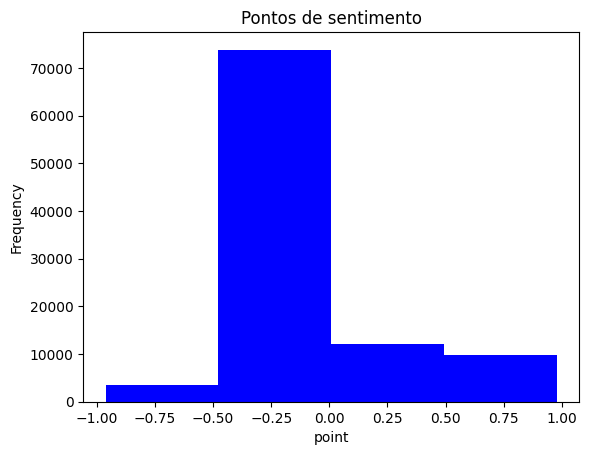

In [60]:

plt.hist(df_review_3['felling_point'], bins=4, color='blue')
plt.title('Pontos de sentimento')
plt.xlabel('point')
plt.ylabel('Frequency')
plt.show()

In [53]:

df_review_clean["review_sentiment"] = (
  df_review_clean["review_comment_message"].apply(get_sentiment_category_from_point)
)


TypeError: '<=' not supported between instances of 'str' and 'float'

In [42]:
df_review_3["felling_point"].sample(10)



,felling_point
4832,0.0000
93171,0.0000
54051,0.0000
95124,0.3612
19734,0.0000
12728,0.0000
62979,-0.2732
34878,0.0000
87802,-0.1134
97853,0.0000


In [ ]:
df_review_clean["words"] = df_review_clean["review_comment_message"].str.split()


counter = df_review_clean.explode("words")

counter


,review_id,review_score,review_comment_title,review_comment_message,review_has_message,review_has_title,words
0,7bc2406110b926393aa56f80a40eba40,4,NaN,NaN,False,False,NaN
1,80e641a11e56f04c1ad469d5645fdfde,5,NaN,NaN,False,False,NaN
2,228ce5500dc1d8e020d8d1322874b6f0,5,NaN,NaN,False,False,NaN
3,e64fb393e7b32834bb789ff8bb30750e,5,NaN,Recebi bem antes do prazo estipulado.,True,False,Recebi
3,e64fb393e7b32834bb789ff8bb30750e,5,NaN,Recebi bem antes do prazo estipulado.,True,False,bem
...,...,...,...,...,...,...,...
99223,efe49f1d6f951dd88b51e6ccd4cc548f,1,NaN,"meu produto chegou e ja tenho que devolver, po...",True,False,defeito
99223,efe49f1d6f951dd88b51e6ccd4cc548f,1,NaN,"meu produto chegou e ja tenho que devolver, po...",True,False,","
99223,efe49f1d6f951dd88b51e6ccd4cc548f,1,NaN,"meu produto chegou e ja tenho que devolver, po...",True,False,não
99223,efe49f1d6f951dd88b51e6ccd4cc548f,1,NaN,"meu produto chegou e ja tenho que devolver, po...",True,False,segurar


In [ ]:
df_review_clean.review_comment_message.str.split().explode().value_counts()

,count
review_comment_message,
o,14802
e,14746
produto,11069
de,10833
do,10813
...,...
devidos,1
hora!,1
refis.,1


In [ ]:
df_review_clean['review_comment_message'].str.contains("bom", regex=True, case=False, na=False)



,review_comment_message
0,False
1,False
2,False
3,False
4,False
...,...
99219,False
99220,False
99221,False
99222,False


In [ ]:
for i in df_review_clean.columns:
  df_review_clean[i].astype('str').apply(lambda x: print(df_review_clean[i].values) if x.startswith('NaN') else 'pass')

Streaming output truncated to the last 5000 lines.
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'NaN' 'NaN' 'NaN']
['NaN' 'NaN' 'NaN' ... 'N

In [ ]:




def check_if_phrase_is_good(text):
  good_words = ["mto", "legal"]
  if text in good_words



,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


3.4 Tabela Avaliações

Avaliações realizadas pelos clientes após a compra.

Observação: Esta é a tabela principal para a análise da relação entre nota e comentário dos clientes.

In [ ]:
df_review.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


3.1 Tabela Pedidos

Representa os pedidos realizados pelos clientes no marketplace

In [ ]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


3.3 Tabela Pagamentos
Informações sobre os pagamentos realizados.

• id_pedido: Identificador do pedido

• sequencial_pagamento: Ordem do pagamento

• tipo_pagamento: Tipo (cartão, boleto, etc.)

• parcelas: Número de parcelas

• valor_pagamento: Valor pago



In [ ]:
df_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


3.2 Tabela Itens do Pedido

Contém os produtos associados a cada pedido.

Dicionário de Dados:

• id_pedido: Identificador do pedido

• id_item: Identificador do item no pedido

• id_produto: Identificador do produto

• id_vendedor: Identificador do vendedor

• data_limite_envio: Data limite para envio

• preco: Preço do produto

• valor_frete: Valor do frete

Observação: Um pedido pode possuir múltiplos itens (relação 1:N).

In [ ]:
df_sales_items.info()

[product_id
df_sales_items
df_products]g

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


3.3 Tabela Pagamentos

Informações sobre os pagamentos realizados.

Dicionário de Dados:

• id_pedido: Identificador do pedido

• sequencial_pagamento: Ordem do pagamento

• tipo_pagamento: Tipo (cartão, boleto, etc.)

• parcelas: Número de parcelas

• valor_pagamento: Valor pago

In [ ]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


3.4 Tabela Avaliações

Avaliações realizadas pelos clientes após a compra.

Dicionário de Dados:

• id_avaliacao: Identificador da avaliação

• id_pedido: Identificador do pedido

• nota: Nota atribuída (1 a 5)

• titulo_comentario: Título da avaliação

• comentario: Texto do comentário

• data_criacao: Data da criação da avaliação

• data_resposta: Data de resposta

In [ ]:
df_review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


3.5 Tabela Clientes

Informações dos clientes do marketplace.

Dicionário de Dados:

• id_cliente: Identificador do cliente

• id_cliente_unico: Identificador único do cliente

• cep: CEP

• cidade: Cidade

• estado: Estado

In [ ]:
df_clients.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


3.6 Tabela Vendedores

Informações dos vendedores.

Dicionário de Dados:

• id_vendedor: Identificador do vendedor

• cep: CEP

• cidade: Cidade

• estado: Estado


In [ ]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


3.7 Tabela Produtos

Informações detalhadas dos produtos.

Dicionário de Dados:

• id_produto: Identificador do produto

• categoria: Categoria do produto

• tamanho_nome: Tamanho do nome do produto

• tamanho_descricao: Tamanho da descrição

• quantidade_fotos: Número de fotos

• peso: Peso do produto

• comprimento: Comprimento

• altura: Altura

• largura: Largura

In [ ]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


3.8 Tabela Geolocalização

Dados geográficos utilizados para análises espaciais.

• cep: CEP

• latitude: Latitude

• longitude: Longitude

• cidade: Cidade

• estado: Estado


In [ ]:
df_geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


4 Início do Projeto - Semana 1

Nesta primeira etapa, cada grupo deverá:



In [ ]:
#df_review = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/avaliacoes.csv")
#df_geo = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/geolocalizacao.csv")
#df_clients = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/clientes.csv")
#df_products = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/produtos.csv")
#df_aux = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/tabela_auxiliar.csv")
#df_sales = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/pedidos.csv")
#df_payments = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/pagamentos.csv")
#df_sales_items = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/itens_pedidos.csv")
#df_sellers = pd.read_csv("/content/drive/MyDrive/cdai/ColabNotebooks/csv/vendedores.csv")

In [ ]:
#• Explorar as bases de dados (visualizar colunas, tipos e valores).

df_review.info()
df_clients.info()
df_sales.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-

In [ ]:
def roda(df):
  df.info()
  df.describe()


d= df_review["review_comment_message"], df_review["review_score"]

d



#Sales
#  custumer_id
#Review
#  order_id
#Clients
#  custumer_id
#Geo

(0                                                      NaN
 1                                                      NaN
 2                                                      NaN
 3                    Recebi bem antes do prazo estipulado.
 4        Parabéns lojas lannister adorei comprar pela I...
                                ...                        
 99219                                                  NaN
 99220                                                  NaN
 99221    Excelente mochila, entrega super rápida. Super...
 99222                                                  NaN
 99223    meu produto chegou e ja tenho que devolver, po...
 Name: review_comment_message, Length: 99224, dtype: object,
 0        4
 1        5
 2        5
 3        5
 4        5
         ..
 99219    5
 99220    5
 99221    5
 99222    4
 99223    1
 Name: review_score, Length: 99224, dtype: int64)

In [ ]:
#• Identificar as relações entre as tabelas


In [ ]:
#• Compreender o fluxo de dados do marketplace:


In [ ]:
#Avaliação, Cliente, Pagamento, Entrega e Pedido. Qual o fluxo correto?
df_review.shape

(99224, 7)

In [ ]:
#• Analisar a variável principal do projeto: nota
# review_score
df_review["review_score"]
df_review["review_comment_message"]



,review_comment_message
0,NaN
1,NaN
2,NaN
3,Recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...
...,...
99219,NaN
99220,NaN
99221,"Excelente mochila, entrega super rápida. Super..."
99222,NaN


In [ ]:
#• Investigar os comentários associados às diferentes notas

5 Foco Analítico do Projeto

O foco principal deste projeto será a análise da relação entre:

• Nota (avaliação numérica de 1 a 5)

• Comentário (opinião textual do cliente)

Os grupos serão divididos em quatro integrantes e deverão investigar questões como:

• Comentários positivos estão associados a notas altas?

• Comentários negativos estão associados a notas baixas?

• Existem casos de incoerência (ex: comentário positivo com nota baixa)?

• Quais palavras aparecem com maior frequência em avaliações boas e ruins?

In [ ]:
#Intervalo temporal
print(df_review["review_creation_date"].min())
print(df_review["review_creation_date"].max())


2016-10-02 00:00:00
2018-08-31 00:00:00


• Quais as dimensões de cada tabela (quantidade de variáveis e informações)?


• Quais tabelas possuem textos (comentários, nomes de produtos entre outros)?

• Quais tabelas possuem valores numéricos (preço, frete, parcelas)?

1

• Para que serve cada tabela dentro do fluxo de um e-commerce?

• Quais colunas funcionam como chaves primárias e quais funcionam como chaves estrangeiras que conectam as tabelas entre si?

• Quais limitações são identificadas dos dados (faltantes, repetidos ou colunas mal preenchidas)?

• Alguma coluna precisa de descrição ou nome mais claro para o dicionário de dados?